In [28]:
# Importing the required library
import numpy as np
import matplotlib.pyplot as plt

In [29]:
# Defining inputs and expected output (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 1, 1, 0])  # Expected output for XOR

In [36]:
def initialize_network_parameters():
    # Network parameters
    inputSize = 2      # Number of input neurons (x1, x2)
    hiddenSize = 2     # Number of hidden neurons
    outputSize = 1     # Number of output neurons
    lr = 0.01           # Learning rate
    epochs = 1000000    # Number of training epochs

    # Initialize weights and biases randomly within the range [-1, 1]
    w1 = np.random.rand(hiddenSize, inputSize) * 2 - 1  # Weights from input to hidden layer
    b1 = np.random.rand(hiddenSize, 1) * 2 - 1          # Bias for hidden layer
    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1 # Weights from hidden to output layer
    b2 = np.random.rand(outputSize, 1) * 2 - 1          # Bias for output layer

    return w1, b1, w2, b2, lr, epochs


## Training the Neural Network

The neural network works in 5 stages: 
1. Forward pass
    * The input **X** is multiplied by the weights **w1** and passed through the first layer, followed by the application of the sigmoid or ReLU activation function. This gives the output for the hidden layer.
    * The output of the hidden layer is then passed through the second set of weights **w2** to compute the final output. Again, a sigmoid activation function is used to generate the final output **a2**.
    
2. Error calculation
    * The error is computed as the difference between the expected output **(d)** and the actual output **(a2)**.
3. Backward pass
    * **Output Layer**: The derivative of the sigmoid activation function is applied to the error, producing the gradient for the output layer **(da2)**. This is used to calculate how much the weights in the output layer need to be adjusted.
    * **Hidden Layer**: The error is then propagated backward to the hidden layer. The gradient at the hidden layer **(da1)** is computed by taking the dot product of the transpose of the weights **(w2.T)** and the gradient from the output layer. The derivative of the activation function (sigmoid or ReLU) is used to adjust this error.
4. Weights and bias updates
    * After computing the **gradients (dz1, dz2)**, the **weights (w1, w2)** and **biases (b1, b2)** are updated using the **learning rate (lr)** and **the gradients**. The updates are done to minimize the error and improve the model’s predictions.
5. Training:
    * This entire process is repeated over many iterations **(epochs)**. During each epoch, the model adjusts its weights and biases to reduce the error. Over time, the network learns to approximate the XOR function.
Forward Pass:



In [31]:
# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

print("Initial weights and biases:")
print("w1:", w1)
print("b1:", b1)
print("w2:", w2)
print("b2:", b2)

Initial weights and biases:
w1: [[-0.55008029 -0.5395698 ]
 [-0.17935806  0.64854016]]
b1: [[-0.29399164]
 [ 0.01971082]]
w2: [[-0.4434997  -0.70281775]]
b2: [[-0.08899486]]


In [32]:

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))

Epoch: 9999, Average error: 0.05444
Epoch: 19999, Average error: 0.03091
Epoch: 29999, Average error: 0.02360
Epoch: 39999, Average error: 0.01975
Epoch: 49999, Average error: 0.01730
Epoch: 59999, Average error: 0.01556
Epoch: 69999, Average error: 0.01425
Epoch: 79999, Average error: 0.01322
Epoch: 89999, Average error: 0.01238
Epoch: 99999, Average error: 0.01168
Epoch: 109999, Average error: 0.01109
Epoch: 119999, Average error: 0.01058
Epoch: 129999, Average error: 0.01013
Epoch: 139999, Average error: 0.00973
Epoch: 149999, Average error: 0.00937
Epoch: 159999, Average error: 0.00905
Epoch: 169999, Average error: 0.00877
Epoch: 179999, Average error: 0.00850


In [33]:
# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('Final output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))


Final output after training: [[0.0078524  0.99110194 0.99108402 0.00834016]]
Ground truth [0 1 1 0]
Error after training: [[-0.00785243  0.00889808  0.00891601 -0.00834018]]
Average error: 0.00850


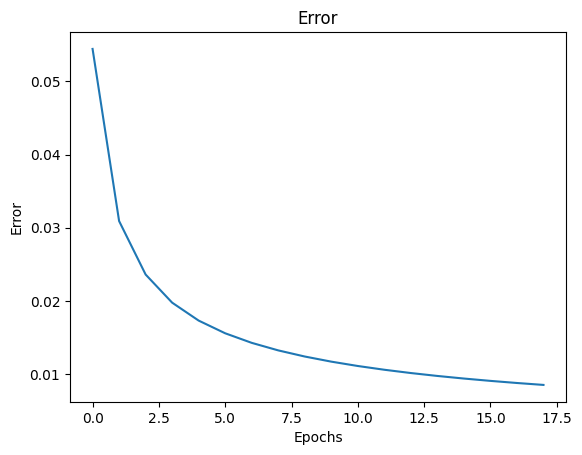

In [34]:
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

Initial weights and biases:
w1: [[-0.23701332  0.0713154 ]
 [ 0.4782964  -0.9982642 ]]
b1: [[0.15155122]
 [0.73652955]]
w2: [[-0.41890852 -0.82350811]]
b2: [[0.69462591]]
Epoch: 9999, Average error: 0.02554
Epoch: 19999, Average error: 0.01632
Epoch: 29999, Average error: 0.01276
Epoch: 39999, Average error: 0.01077
Epoch: 49999, Average error: 0.00946
Epoch: 59999, Average error: 0.00853
Epoch: 69999, Average error: 0.00782
Epoch: 79999, Average error: 0.00725
Epoch: 89999, Average error: 0.00679
Epoch: 99999, Average error: 0.00640
Epoch: 109999, Average error: 0.00607
Epoch: 119999, Average error: 0.00579
Epoch: 129999, Average error: 0.00554
Epoch: 139999, Average error: 0.00532
Epoch: 149999, Average error: 0.00512
Epoch: 159999, Average error: 0.00495
Epoch: 169999, Average error: 0.00478
Epoch: 179999, Average error: 0.00464
Final output after training: [[1.81822454e-04 4.72807736e-03 4.90114525e-03 9.91257620e-01]]
Ground truth [0 0 0 1]
Error after training: [[-0.00018182 -0.0

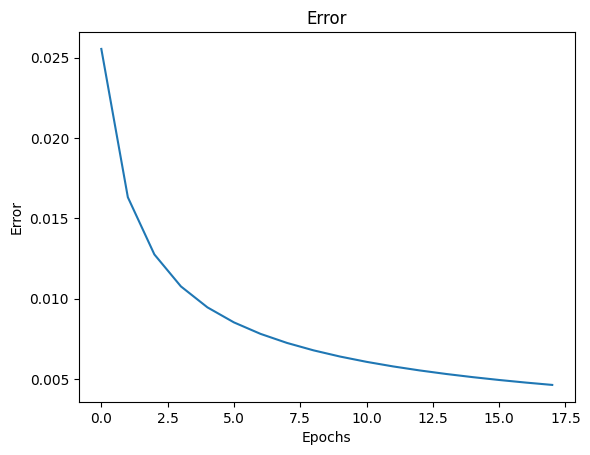

In [35]:
# Defining inputs and expected output (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 0, 0, 1])  # Expected output for XOR

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

print("Initial weights and biases:")
print("w1:", w1)
print("b1:", b1)
print("w2:", w2)
print("b2:", b2)


# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))

# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('Final output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

Initial weights and biases:
w1: [[-0.29656825  0.23737158]
 [ 0.57082599  0.7892406 ]]
b1: [[ 0.95680117]
 [-0.63428858]]
w2: [[-0.95991484 -0.58345766]]
b2: [[-0.87792274]]
Epoch: 9999, Average error: 0.19294
Epoch: 19999, Average error: 0.08414
Epoch: 29999, Average error: 0.05583
Epoch: 39999, Average error: 0.04333
Epoch: 49999, Average error: 0.03618
Epoch: 59999, Average error: 0.03148
Epoch: 69999, Average error: 0.02812
Epoch: 79999, Average error: 0.02558
Epoch: 89999, Average error: 0.02358
Epoch: 99999, Average error: 0.02196
Epoch: 109999, Average error: 0.02060
Epoch: 119999, Average error: 0.01946
Epoch: 129999, Average error: 0.01848
Epoch: 139999, Average error: 0.01762
Epoch: 149999, Average error: 0.01686
Epoch: 159999, Average error: 0.01619
Epoch: 169999, Average error: 0.01559
Epoch: 179999, Average error: 0.01504
Epoch: 189999, Average error: 0.01455
Epoch: 199999, Average error: 0.01410
Epoch: 209999, Average error: 0.01368
Epoch: 219999, Average error: 0.01330
E

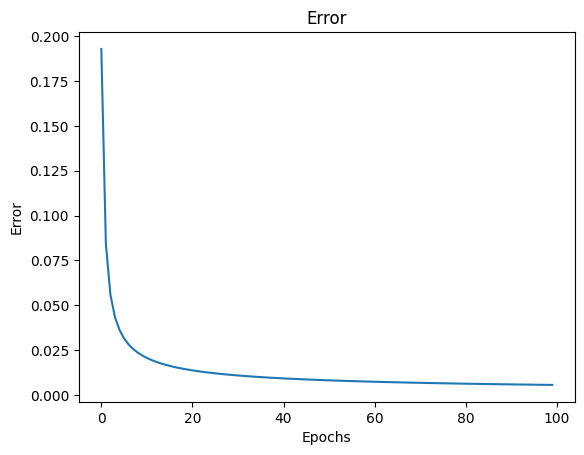

In [37]:
# Defining inputs and expected output (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 0, 0, 1])  # Expected output for XOR

# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

print("Initial weights and biases:")
print("w1:", w1)
print("b1:", b1)
print("w2:", w2)
print("b2:", b2)


# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))

# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('Final output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()